   area  bedrooms  bathrooms  floors  age  distance  garage  parking  garden  \
0  1360         6          2       2    9        10       0        0       1   
1  4272         5          2       3   24         8       1        0       0   
2  3592         1          4       3    4        20       0        1       1   
3   966         5          2       2    6        14       1        0       0   
4  4926         4          3       1   18         9       0        0       0   

   security  school_nearby  hospital_nearby  shopping_mall_nearby  \
0         0              1                0                     1   
1         1              1                1                     1   
2         1              0                1                     0   
3         0              0                1                     1   
4         0              1                0                     1   

   public_transport  crime_rate  population_density location income_level  \
0                 0    6.93

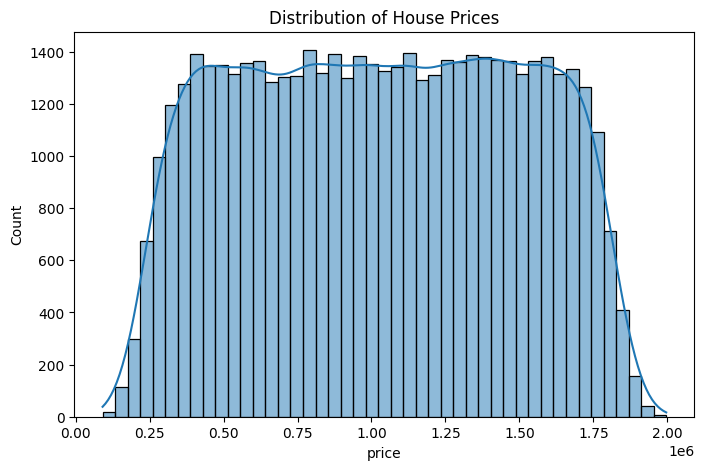

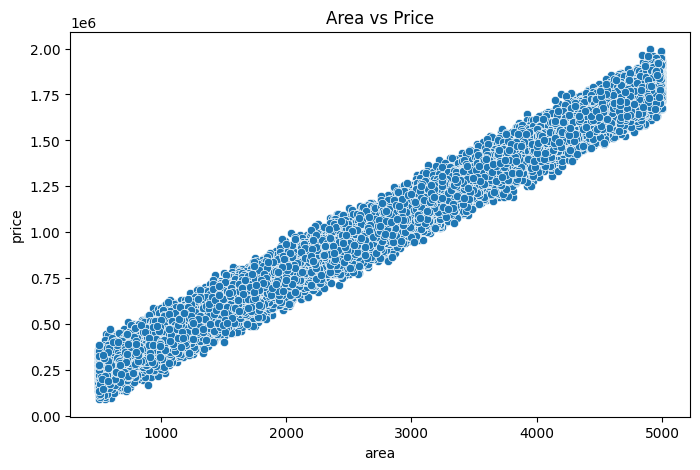

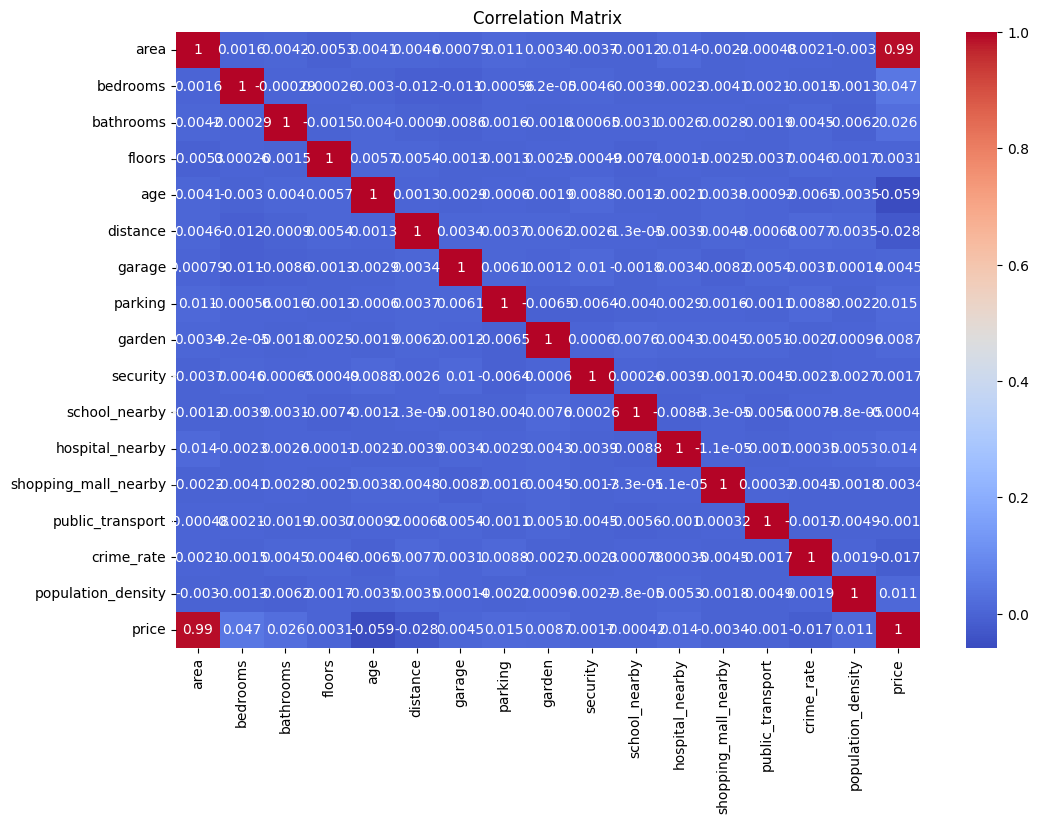

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("house_price_50k.csv")

# Display first 5 rows
print(df.head())

# ==========================
# UNIVARIATE ANALYSIS
# ==========================

# Replace 'price' with your target column name if different
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# ==========================
# BIVARIATE ANALYSIS
# ==========================

# Replace 'area' with a numerical feature in your dataset
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['area'], y=df['price'])
plt.title("Area vs Price")
plt.show()

# ==========================
# MULTIVARIATE ANALYSIS
# ==========================

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

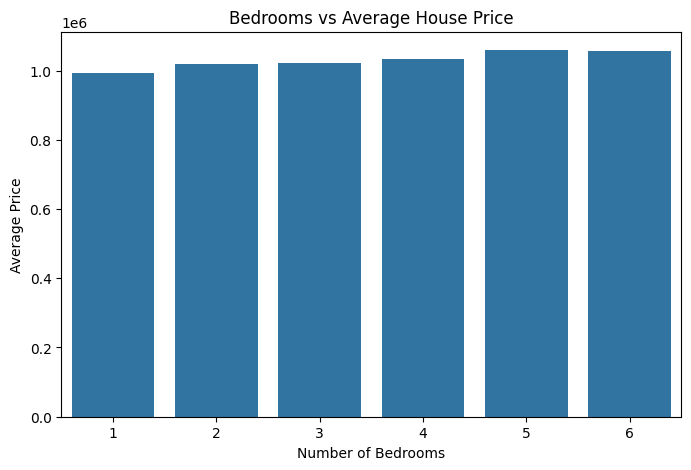

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("house_price_50k.csv")

# Average price by bedrooms
bedroom_price = df.groupby('bedrooms')['price'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=bedroom_price, x='bedrooms', y='price')
plt.title("Bedrooms vs Average House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.show()

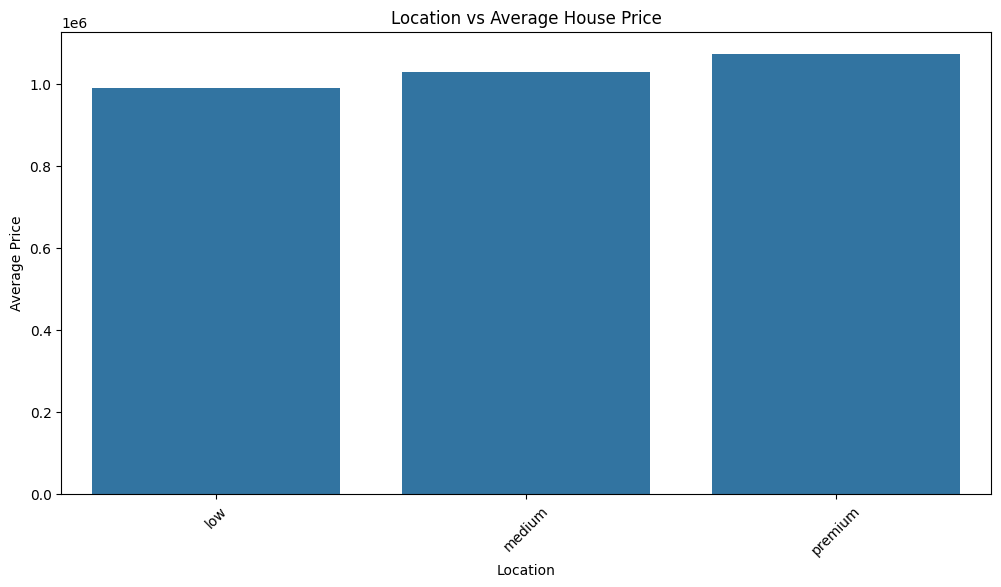

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("house_price_50k.csv")

# Average price by location
location_price = df.groupby('location')['price'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=location_price, x='location', y='price')
plt.title("Location vs Average House Price")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

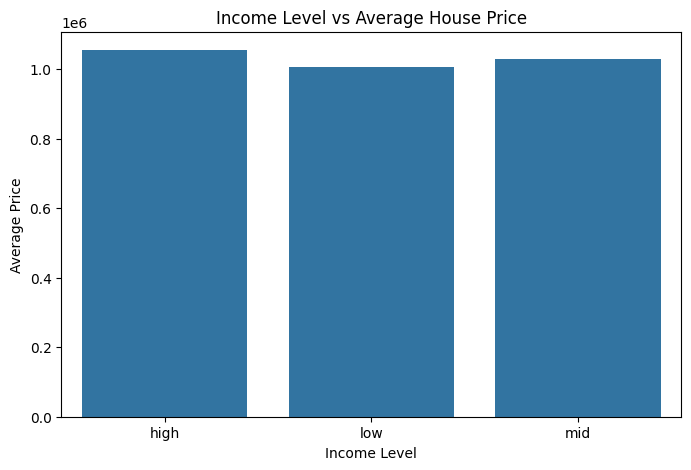

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("house_price_50k.csv")

# Average price by income level
income_price = df.groupby('income_level')['price'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=income_price, x='income_level', y='price')

plt.title("Income Level vs Average House Price")
plt.xlabel("Income Level")
plt.ylabel("Average Price")
plt.show()

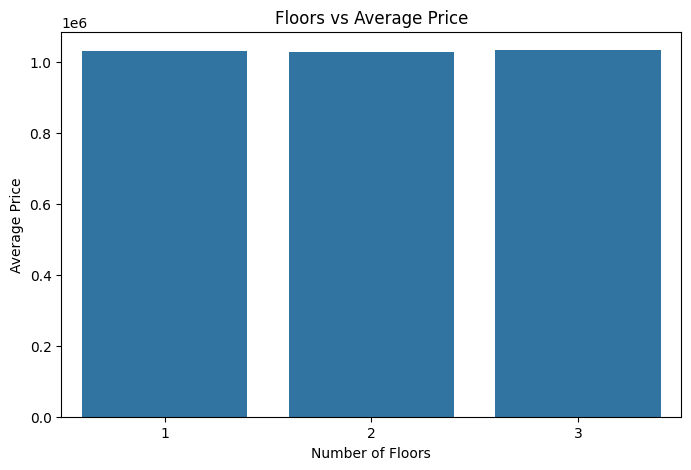

In [7]:
floors_price = df.groupby('floors')['price'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=floors_price, x='floors', y='price')
plt.title("Floors vs Average Price")
plt.xlabel("Number of Floors")
plt.ylabel("Average Price")
plt.show()

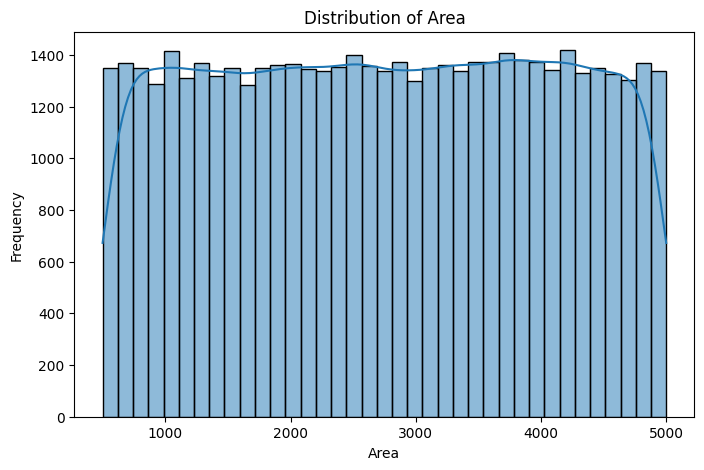

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['area'], kde=True)
plt.title("Distribution of Area")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

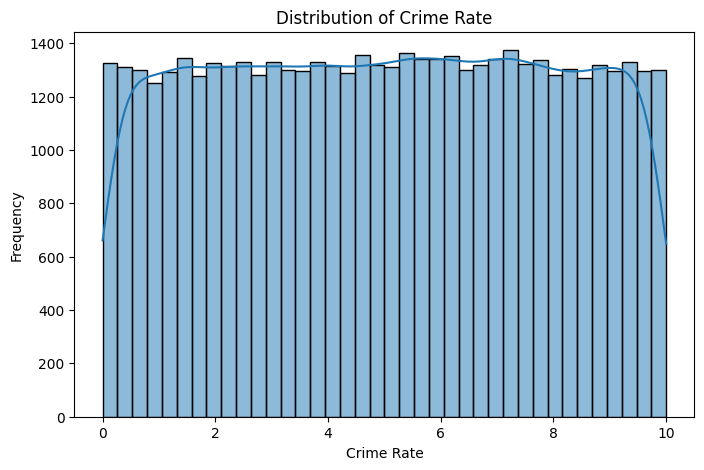

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['crime_rate'], kde=True)
plt.title("Distribution of Crime Rate")
plt.xlabel("Crime Rate")
plt.ylabel("Frequency")
plt.show()

In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("house_price_50k.csv")

# 1. Total Rooms
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

# 2. House Age Category
df['age_category'] = pd.cut(
    df['age'],
    bins=[0, 5, 15, 30, 100],
    labels=['New', 'Moderate', 'Old', 'Very_Old']
)

# 3. Nearby Facilities Count
df['facility_count'] = (
    df['school_nearby'] +
    df['hospital_nearby'] +
    df['shopping_mall_nearby'] +
    df['public_transport']
)

# 4. Security Score
df['security_score'] = (
    df['security'] +
    df['garage'] +
    df['parking']
)

# 5. Luxury Score
df['luxury_score'] = (
    df['garden'] +
    df['garage'] +
    df['parking'] +
    df['security']
)

# 6. Area Per Bedroom
df['area_per_bedroom'] = df['area'] / df['bedrooms']

# 7. Area Per Bathroom
df['area_per_bathroom'] = df['area'] / df['bathrooms']

# 8. Population-Crime Interaction
df['crime_population_ratio'] = (
    df['crime_rate'] / (df['population_density'] + 1)
)

# 9. Income-Area Interaction
df['income_area_score'] = (
    df['income_level'] * df['area']
)

# 10. Floors Per Bedroom
df['floor_bedroom_ratio'] = (
    df['floors'] / df['bedrooms']
)

# Convert categorical feature to numerical
df = pd.get_dummies(df, columns=['location', 'age_category'], drop_first=True)

# Save engineered dataset
df.to_csv("house_price_feature_engineered.csv", index=False)

print("Feature Engineering Completed!")
print(df.head())

Feature Engineering Completed!
   area  bedrooms  bathrooms  floors  age  distance  garage  parking  garden  \
0  1360         6          2       2    9        10       0        0       1   
1  4272         5          2       3   24         8       1        0       0   
2  3592         1          4       3    4        20       0        1       1   
3   966         5          2       2    6        14       1        0       0   
4  4926         4          3       1   18         9       0        0       0   

   security  ...  area_per_bedroom  area_per_bathroom  crime_population_ratio  \
0         0  ...        226.666667              680.0                0.000958   
1         1  ...        854.400000             2136.0                0.000052   
2         1  ...       3592.000000              898.0                0.005816   
3         0  ...        193.200000              483.0                0.001006   
4         0  ...       1231.500000             1642.0                0.000349   

 

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

# Load dataset
df = pd.read_csv("house_price_50k.csv")

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop("price", axis=1)
y = df["price"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================
# Decision Tree Regressor
# ==========================
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Results")
print("R2 Score :", r2_score(y_test, dt_pred))
print("MAE :", mean_absolute_error(y_test, dt_pred))
print()

# ==========================
# Random Forest Regressor
# ==========================
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("R2 Score :", r2_score(y_test, rf_pred))
print("MAE :", mean_absolute_error(y_test, rf_pred))
print()

# ==========================
# XGBoost Regressor
# ==========================
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results")
print("R2 Score :", r2_score(y_test, xgb_pred))
print("MAE :", mean_absolute_error(y_test, xgb_pred))

C:\Users\rishi\AppData\Local\Temp\ipykernel_25696\1461590647.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


Decision Tree Results
R2 Score : 0.9909857751627545
MAE : 34493.87405842033

Random Forest Results
R2 Score : 0.9963968495787425
MAE : 21960.494225229762

XGBoost Results
R2 Score : 0.9977424320234569
MAE : 17474.3080434744


In [12]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results")
print("R2 Score :", r2_score(y_test, xgb_pred))
print("MAE :", mean_absolute_error(y_test, xgb_pred))

XGBoost Results
R2 Score : 0.9977424320234569
MAE : 17474.3080434744


In [14]:
import streamlit as st
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

st.title("Train Model")

if st.button("Train Model"):

    df = pd.read_csv("house_price_50k.csv")

    X = df.drop("price", axis=1)
    y = df["price"]

    X = pd.get_dummies(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = r2_score(y_test, pred)

    joblib.dump(model, "model.pkl")
    joblib.dump(X.columns.tolist(), "columns.pkl")

    st.success(f"Model Trained Successfully")
    st.write(f"Accuracy: {accuracy:.4f}")

2026-06-16 11:36:51.243 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 11:36:51.454 
  command:

    streamlit run C:\Users\rishi\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-16 11:36:51.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 11:36:51.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 11:36:51.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 11:36:51.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 11:36:51.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 11:36:51.458 Thre

In [15]:
joblib.dump(model, "model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

NameError: name 'model' is not defined